## This notebook is for EDA of jsonl data from the evaluated chess positons from stockfish of games where both white and black players are >2200 ELO.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_json('output/evaluated_positions.jsonl', lines=True)

In [3]:
print(len(df))

100011


**We want to look for a unimodal histogram at 0.5 as high elo should be near draw for most of the game, and some slight wins and losses at 0.0 and 1.0**

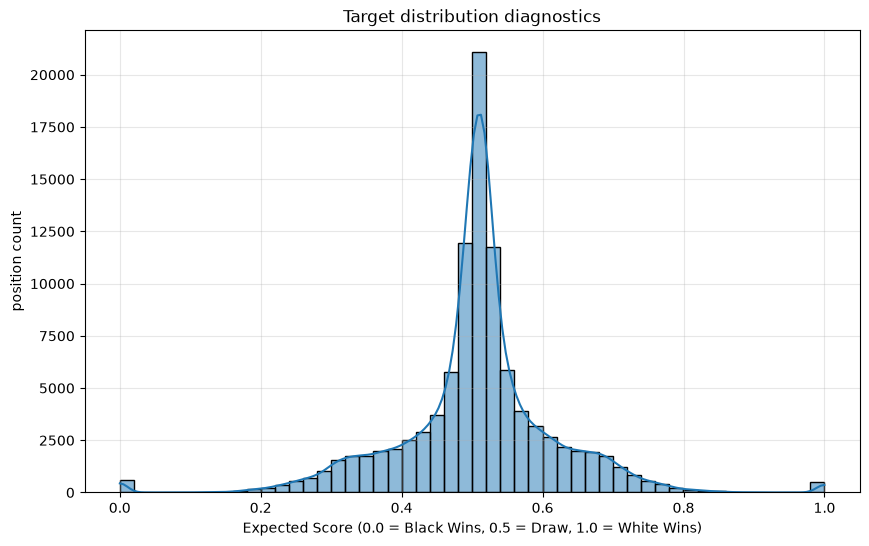

In [4]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="target", bins=50, kde=True)

plt.title("Target distribution diagnostics")
plt.xlabel("Expected Score (0.0 = Black Wins, 0.5 = Draw, 1.0 = White Wins)")
plt.ylabel("position count")
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# Seeing how many moves are duplicates, should be lower due to random 4-6 game thinning
duplicate_count = df['fen'].duplicated().sum()
print(f"Duplicate positions: {duplicate_count}")

Duplicate positions: 5651


In [6]:
# moves analysis
df['fullmove'] = df['fen'].apply(lambda x: int(x.split(' ')[5]))
df['halfmove_clock'] = df['fen'].apply(lambda x: int(x.split(' ')[4]))

In [7]:
# Drop duplicates, only keeping first occurence of a specific FEN(move) string
df_cleaned = df.drop_duplicates(subset=['fen']).reset_index(drop=True)
print(f"Original size: {len(df)} | Deduplicated size: {len(df_cleaned)}")

Original size: 100011 | Deduplicated size: 94360


** We want to look for a peak around 15-20 full moves as high elo games contain more games at middle game and more training nuance than early game/late game**

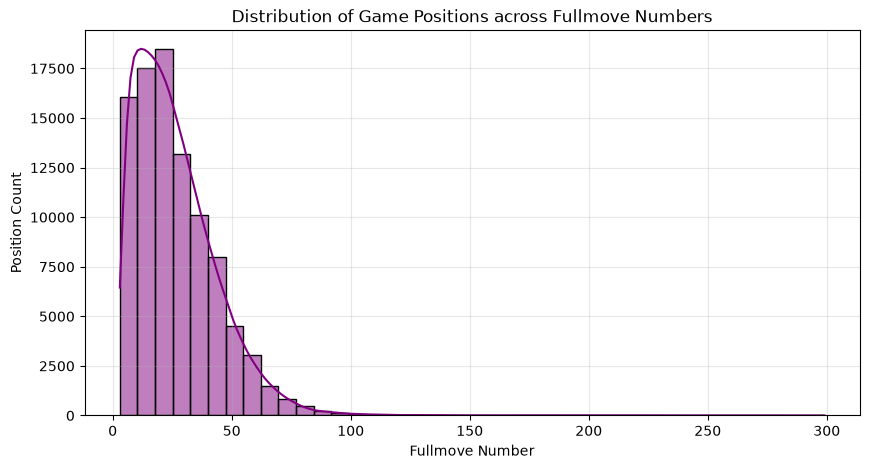

In [8]:
# Plot the Fullmove Number Distribution
plt.figure(figsize=(10, 5))
sns.histplot(data=df_cleaned, x="fullmove", bins=40, kde=True, color='purple')
plt.title("Distribution of Game Positions across Fullmove Numbers")
plt.xlabel("Fullmove Number")
plt.ylabel("Position Count")
plt.grid(True, alpha=0.3)
plt.show()